In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:90% ! important;}
div.cell.code_cell.rendered{width:100%}
div.input_prompt{padding:0px}
div.CodeMirror {font-family:Consolas ; font-size:12pt;}
div.text_cell_render.rendered_html {font-size:12pt;}
div.output {font-size:12pt; font-weight:bold}
div.input {font-family:Consolas ; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper {padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:12px;}
</style>
"""))

<b><font size ='6' color='red'>ch3 분류분석</font></b>
# 1절 분류분석 개요
## 1-1 분류분석이란?
- 타겟변수가 categorical 변수인 분석
    - 수업ex. mnist 숫자예측, iris 분류예측, 와인등급 예측, 질병예측
    - ex. 고객등급예측, 휴먼고객예측, 상품구매예측, 보험사기예측
- sklearn 패키지 : 예제 데이터셋, 전저리, 머신러닝 모형
## 1-2 샘플용 데이터 셋 접근
### load 계열(패키지 내에 데이터 있음)
- load_iris(), load_boston(), load_diabets()....
### fetch계열(패키지 내에 데이터 없음, 인터넷 연결 시 다운)
- fetch_openml(), fetch_rov1(로이터 뉴스 말뭉치)
### make계열(가상의 데이터 생성)
- make_classification() : 분류분석용 데이터 생성
- make_regression() : 회귀분석용 데이터 생성
- make_blobs() : 군집분석용 데이터 생성(타겟변수x)

In [4]:
# load 계열
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
(X_train,y_train), (X_test, y_test) = mnist.load_data()
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

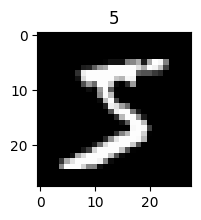

In [10]:
# 첫번쨰 이미지 출력
plt.figure(figsize=(2,2))
plt.imshow(X_train[0], cmap='gray')
plt.title(y_train[0])
plt.show()

In [12]:
# fetch 계열
from sklearn.datasets import fetch_openml
mnist = fetch_openml(name="mnist_784", 
                     version=1,
                     as_frame=False, # 데이터프레임으로 받을 지 여부(False:넘파이 배열)
                     parser="auto")
X, y = mnist.data, mnist.target.astype('int')
X.shape, y.shape

((70000, 784), (70000,))

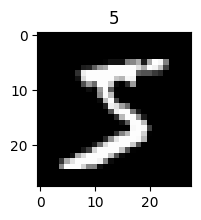

In [13]:
# 첫번째 이미지 출력
plt.figure(figsize=(2,2))
plt.imshow(X[0].reshape(28,28), cmap='gray')
plt.title(y[0])
plt.show()

# 2절. 분류모형의 종류
- predict()
## 2-1 확률적 모형
    - 주어진 데이터에 각 클래스가 정답일 확률을 계산하는 모형
    - predict_proba() : 각 분류 클래스별 확률을 알려줌(일부 판별함수 모형에 있기는 함)
    - predict_log_proba() : 확률의 로그값을 알려줌
    
### 1) 확률적 생성 모형
    - 각 클래스별 특징 데이터 확률분포 추정하는 방식. 소량의 데이터로도 작동
    - ex. QuadraticDiscriminantAnalysis, MultinomialNB
    
### 2) 확률적 판별 모형
    - 확률을 계산하는 함수 이용
    - ex. 의사결정나무, 로지스틱 회귀분석
    
## 2-2 판별함수 모형
    - 주어진 데이터를 클래스에 따라 다른 영역으로 나누는 경계면을 찾은 후, 
    - 이 경계면을 계산 식 = > 판별함수
    - dicision_function()
    - ex 퍼셉트론, SVM, MLP(신경망)
=> RandomForest, LGBM, XGBoost, CatBoost등의 앙상블 모형이 더 많이 쓰임

# 3절. 모형1:  확률적 생성 모형
- 베이즈 정리를 사용하여 확률 분포 계산
## 3-1 QDA
- x 가 연속형(실수)이면 정규분포라고 가정함

In [18]:
# 샘플 데이터
from sklearn.datasets import make_classification
X,y = make_classification(n_features=2, # 독립변수 갯수
                          n_informative=2, # 타겟 변수에 영향을 주는 독립 변수 갯수
                          n_redundant=0, # 타겟 변수에 영향을 주지 않는 독립 변수 갯수
                          n_clusters_per_class=1, # 클래스 내서브그룹수
                          n_classes=2, # 타겟변수의 class 수
                          n_samples=100, # 데이터 갯수(행수) 100이 기본값
                          random_state=9 # seed 값
                         )
X.shape, y.shape

((100, 2), (100,))

In [19]:
import numpy as np
np.unique(y)

array([0, 1])

In [20]:
# 타겟변수의 클래스 균형[]
import pandas as pd
pd.Series(y).value_counts()

0    50
1    50
dtype: int64

In [21]:
# y = 1로 분류된 데이터
X[y==1]

array([[ 1.52078971,  1.35691103],
       [ 2.45860885,  2.19689248],
       [ 1.25550571,  1.43114764],
       [-0.15086066, -0.06521048],
       [ 0.09781527,  0.16537075],
       [-1.65468869, -1.31517916],
       [-0.85284991, -0.74271133],
       [-0.00999512,  0.17472667],
       [ 1.14618495,  1.18569524],
       [ 3.60142362,  3.32861337],
       [ 1.50231958,  1.36649091],
       [ 2.37501885,  2.07760314],
       [ 2.8263622 ,  2.6930792 ],
       [ 1.09118724,  1.04060759],
       [ 3.32323633,  2.94877458],
       [ 3.32155981,  3.0433048 ],
       [-1.37317687, -1.01903515],
       [ 0.51649579,  0.62849738],
       [-0.34111809, -0.09912124],
       [ 1.38859164,  1.16051562],
       [ 3.05449394,  2.66236122],
       [ 2.5232377 ,  2.34537053],
       [ 0.71080623,  0.70665028],
       [ 2.04902895,  1.90382742],
       [ 2.76472511,  2.64993681],
       [-0.36733303, -0.0739366 ],
       [ 1.29278311,  1.28542309],
       [ 0.76654703,  0.88953436],
       [ 0.70968868,

In [23]:
# 타겟변수의 클래스 균형
y.mean()

0.5

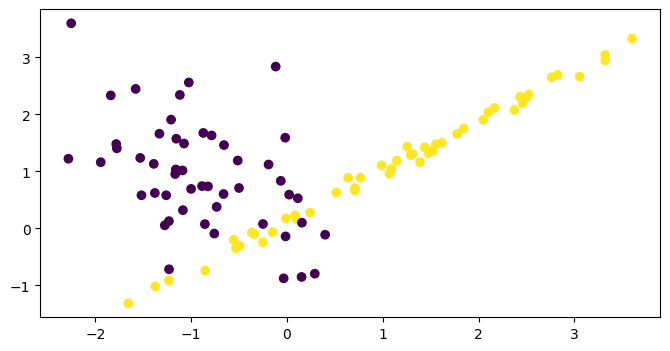

In [24]:
plt.figure(figsize=(8,4))
plt.scatter(x=X[:,0], y=X[:,1], c=y)

In [25]:
# (0,0) 기준으로 대칭구조
X[y==1] = -X[y==0]

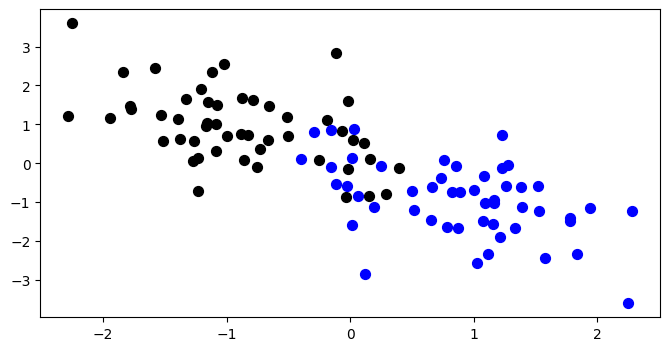

In [30]:
plt.figure(figsize=(8,4))
plt.scatter(x=X[y==0, 0], y=X[y==0,1], c='k', s=50, edgecolors='k')
plt.scatter(x=X[y==1, 0], y=X[y==1,1], c='b', s=50)

In [32]:
# QDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
model = QuadraticDiscriminantAnalysis()
model.fit(X,y)

QuadraticDiscriminantAnalysis()

In [37]:
x = [[0.5,0], [0,0],[-0.5,0]] #predict할 때는 2차원 데이터로
model.predict(x)

array([1, 0, 0])

In [40]:
model.predict_proba(x)

array([[0.16455419, 0.83544581],
       [0.5       , 0.5       ],
       [0.83544581, 0.16455419]])

In [39]:
model.classes_

array([0, 1])

In [43]:
y_hat = model.predict(X)
pd.crosstab(y, y_hat)

col_0,0,1
row_0,,
0,44,6
1,6,44


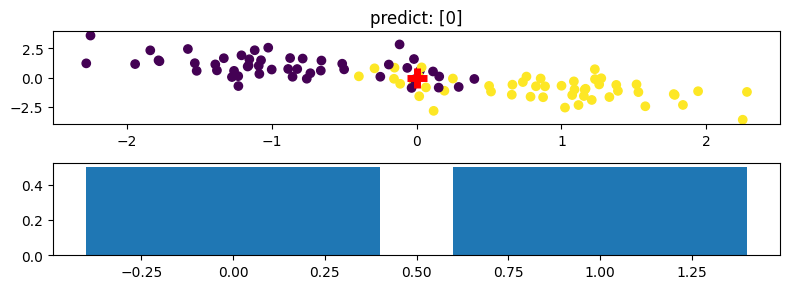

In [51]:
x=[[0,0]]
plt.figure(figsize=(8,3))
p = model.predict_proba(x)
plt.subplot(211) # 2행 1열로 subplot에서 첫번째 그래프
plt.scatter(x=X[:,0], y = X[:,1], c=y)
plt.scatter(x=x[0][0], y= x[0][1], c='r', s=200, marker='+', lw=5)
h=model.predict(x)
plt.title(f'predict: {h}')
plt.subplot(212)
plt.bar(model.classes_, p[0])
plt.tight_layout()
plt.show()

## 3-2 나이브베이지안 모형

In [60]:
# 데이터
import seaborn as sns
iris = sns.load_dataset('iris')
# 학습데이터는 numpy 배열로 하는 것을 추천
X = iris.iloc[:,:-1].values # 넘파일로 변환
y = iris.iloc[:,-1].values # 라벨인코딩없이 넘파이 배열로 변환
# 모형 생성 학습
from sklearn.naive_bayes import MultinomialNB
model = MultinomialNB()
model.fit(X,y)

MultinomialNB()

In [56]:
X.loc[0]

sepal_length    5.1
sepal_width     3.5
petal_length    1.4
petal_width     0.2
Name: 0, dtype: float64

In [64]:
x = [[5.1, 3.5, 1.4, 0.2]]
h = model.predict(x)
p = model.predict_proba(x)
print('예측 :', h)
print(model.classes_)
print(p)

예측 : ['setosa']
['setosa' 'versicolor' 'virginica']
[[0.75199536 0.16092948 0.08707516]]


<BarContainer object of 3 artists>

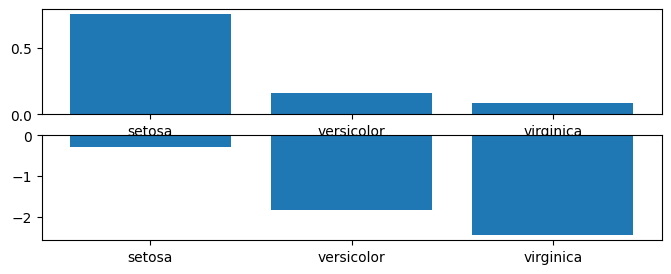

In [67]:
plt.figure(figsize=(8,3))
plt.subplot(211) # 2행 1열로 subplot에서 첫번째 그래프
plt.bar(model.classes_, model.predict_proba(x)[0])
plt.subplot(2,1,2)
# plt.bar(model.classes_, model.predict_log_proba(x)[0])
plt.bar(model.classes_, np.log(model.predict_proba(x))[0])

# 4절 모형2. 확률적 판별모형
## 4-1 로지스틱 회귀분석

In [99]:
# 샘플 데이터
from sklearn.datasets import make_classification
X,y = make_classification(n_features=1, # 독립변수 갯수
                          n_informative=1, # 타겟 변수에 영향을 주는 독립 변수 갯수
                          n_redundant=0, # 타겟 변수에 영향을 주지 않는 독립 변수 갯수
                          n_clusters_per_class=1, # 클래스 내서브그룹수
                          n_classes=2, # 타겟변수의 class 수
                          n_samples=100, # 데이터 갯수(행수) 100이 기본값
                          random_state=1 # seed 값
                         )
X.shape, y.shape

((100, 1), (100,))

In [100]:
# 타겟변수의 클레벨 균형
print(y.mean())

0.5


In [101]:
# 모형
from sklearn.linear_model import LogisticRegression
model = LogisticRegression().fit(X,y)

In [108]:
# -3부터 3까지 같은 간격 데이터
xx = np.linspace(-3,3,100)

test_x = xx.reshape(-1,1)
y_hat = model.predict(test_x)
prob = model.predict_proba(test_x)

In [112]:
# prob[:,0] # 0으로 분류될 확률
# prob[:,1] # 1으로 분류될 확률

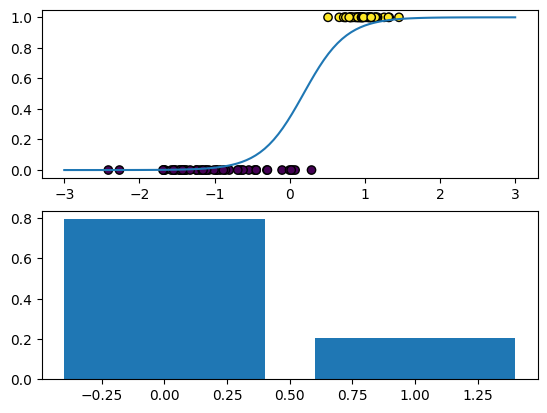

In [118]:
x = [[-0.2]]
plt.subplot(211)
plt.scatter(X,y, c=y, edgecolors='k')
plt.plot(xx, prob[:, 1])
plt.subplot(212)
prob_x = model.predict_proba(x)[0]
plt.bar(model.classes_, prob_x)
plt.show()

## 4-2 의사결정나무
- 여러가지 규칙을 순차적으로 적용하면서 독립변수 공간을 분할하는 분류모형
- ★ 종속변수에 영행을 주는 독립변수들을 알아보는 목적

In [131]:
from sklearn.datasets import load_iris
data = load_iris()
X = data.data[:,2:] # petal_length, petal_width
# data.target_names[data.target]
y = data.target
data.feature_names[:2]
feature_names = [name[:-5].replace(' ','_') for name in data.feature_names[2:]]

In [136]:
# 모형
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(criterion='entropy', # 품질기준을 entropy
                                  max_depth=1,
                                  random_state=0
                                 )
dt_model.fit(X,y) # depth 1의 tree라 성능이 낮음

DecisionTreeClassifier(criterion='entropy', max_depth=1, random_state=0)

In [140]:
dt_model.predict(X)

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

생성된 tree 시각화

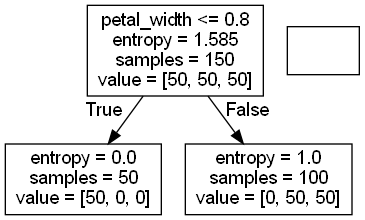

In [144]:
from sklearn.tree import export_graphviz
import pydot
from IPython.core.display import Image
import io
def draw_decision_tree(model, feature_names):
    dot_buf = io.StringIO()
    export_graphviz(model, out_file=dot_buf, feature_names=feature_names)
    graph = pydot.graph_from_dot_data(dot_buf.getvalue())[0]
    image = graph.create_png()
    return Image(image)
draw_decision_tree(dt_model, feature_names)

In [149]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

def plot_decision_regions(X, y, model, title):
    species = ['setosa', 'versicolor', 'virginica']
    resolution = 0.01
    markers = ('s', '^', 'o')
    colors = ('red', 'blue', 'lightgreen')
    cmap = mpl.colors.ListedColormap(colors)
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
        np.arange(x2_min, x2_max, resolution))
    Z = model.predict(
        np.array([xx1.ravel(), xx2.ravel()]).T).reshape(xx1.shape)
    plt.contour(xx1, xx2, Z, cmap=mpl.colors.ListedColormap(['k']))
    plt.contourf(xx1, xx2, Z, alpha=0.4, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0], y=X[y == cl, 1], alpha=0.8,
        c=[cmap(idx)], marker=markers[idx], s=80, label=species[cl])
    plt.xlabel(data.feature_names[2])
    plt.ylabel(data.feature_names[3])
    plt.legend(loc='upper left')
    plt.title(title)
    return Z

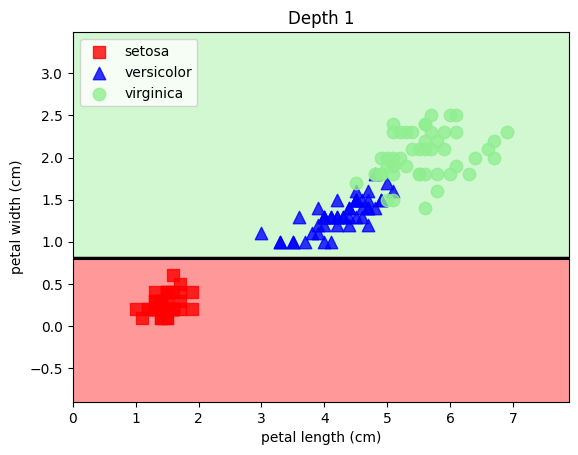

In [151]:
plot_decision_regions(X,y,dt_model, 'Depth 1')
plt.show()

In [152]:
dt_model5 = DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=0)
dt_model5.fit(X,y)

DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=0)

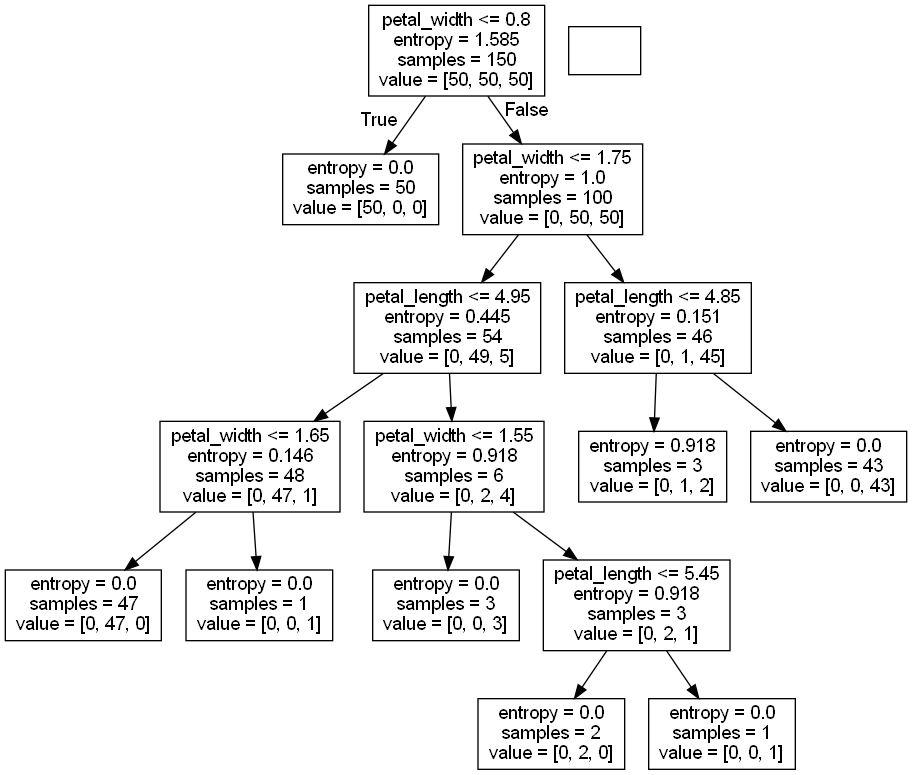

In [153]:
draw_decision_tree(dt_model5, feature_names=feature_names)

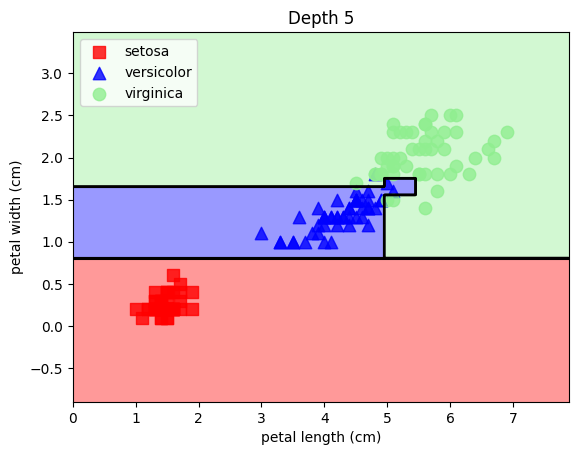

In [154]:
plot_decision_regions(X,y,dt_model5, 'Depth 5')
plt.show()

In [155]:
dt_model5.predict(X)

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

# 5절. 모형3 : 판별함수 모형
- 동일한 클래스가 모여있는 영역과 그 영역을 나누는 경계면을 정의
- decision_function() 제공
- 퍼셉트론, SVN, 인공신경망모형(일부는 predict_proba도 있음)
## 5-1 Perceptron

In [160]:
import pandas as pd

iris = load_iris()

# 0, 2(setosa, virginica)만
# idx = np.in1d(iris.target, [0,2])
idx = pd.Series(iris.target).isin([0,2]).values

In [162]:
X =iris.data[idx, :2]
y = iris.target[idx]
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [164]:
# 퍼셉트론 모형
from sklearn.linear_model import Perceptron
model = Perceptron(max_iter=500, # epoch 500회
                   eta0=0.1, #Learnig rate
                   random_state=1
                  ).fit(X,y)

In [165]:
y_hat = model.predict(X)
y_hat

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0,
       0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [167]:
(y != y_hat).sum()

1

In [169]:
# 예측값이 틀린 경우
X[y!=y_hat]

array([[4.5, 2.3]])

In [172]:
for idx, (real,hat) in enumerate(zip(y, y_hat)):
    # print(idx, real, hat)
    if real != hat:
        print(f'{idx}번제 실제 값 :{real}, 예측값 : {hat} = 데이터 : {X[idx]}')

41번제 실제 값 :0, 예측값 : 2 = 데이터 : [4.5 2.3]


In [177]:
test_x = X[41].reshape(1,-1)
test_x = X[41][np.newaxis, :]
test_x = np.expand_dims(X[41], axis=0)
test_x =X[41][None, :]
print(model.predict(test_x))
print(model.decision_function(test_x))

[2]
[1.24]


In [178]:
test_x = X[50].reshape(1,-1)
print(model.decision_function(test_x))

[2.028]


## 5-2 SVC
- Support Vector Classifier

In [186]:
from sklearn.svm import SVC
model = SVC(probability=True)
model.fit(X,y)

SVC(probability=True)

In [187]:
test_x = X[41].reshape(1,-1)
print(test_x)
print('예측 :', model.predict(test_x))
print('경계면과의 거리 :', model.decision_function(test_x))
print('예측 확률들 :', model.predict_proba(test_x))

[[4.5 2.3]]
예측 : [0]
경계면과의 거리 : [-0.72539221]
예측 확률들 : [[0.90217767 0.09782233]]


## 5-3 다중 퍼셉트론(인공신경망)
- predict / decision_function / predict_proba/ predict_log_proba

In [193]:
# 데이터 불러오기
from sklearn.datasets import load_iris
iris = load_iris()
iris_X = iris.data
iris_y = iris.target
iris_X.shape, iris_y.shape
from sklearn.model_selection import train_test_split
train_X, test_X, train_y, test_y = train_test_split(iris_X, iris_y,
                                                   test_size=0.3,
                                                   random_state=1,
                                                   stratify=iris_y) # 층화추출

In [195]:
# 다중 퍼셉트론 모형
from sklearn.neural_network import MLPClassifier
mlp = MLPClassifier(hidden_layer_sizes=(50,50,30), # hidden layer의  unit수
                    max_iter=500 # epoche
                   )
mlp.fit(train_X, train_y)

MLPClassifier(hidden_layer_sizes=(50, 50, 30), max_iter=500)

In [197]:
pred = mlp.predict(test_X)
pd.crosstab(test_y, pred)

col_0,0,1,2
row_0,,,
0,15,0,0
1,0,15,0
2,0,0,15


# 6절. 분류모형 성능평가
## 6-1 혼돈행렬 이용
- metrics 모듈 : ~.score
- 혼돈행렬을 이용

In [ ]:
y_true = [1, 1, 0, 0, 2, 1, 0, 2, 2] # 실제값
y_pred = [1, 2, 0, 1, 1, 0, 0, 2, 1] # 예측값

In [199]:
result = pd.read_csv('data/model_result.csv') # 보험 사기자인지 여부(실제값/예측값)
result.info() # 타입과결측치, 메모리 사용

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1793 entries, 0 to 1792
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   CUST_ID  1793 non-null   int64
 1   y_true   1793 non-null   int64
 2   y_pred   1793 non-null   int64
dtypes: int64(3)
memory usage: 42.1 KB


In [201]:
# 실제 보험사기자, 보험사기자로 예측 
result['y_true'].sum(), result['y_pred'].sum()

(158, 99)

In [202]:
pd.crosstab(result.y_true, result.y_pred, margins=True)

y_pred,0,1,All
y_true,,,
0,1613,22,1635
1,81,77,158
All,1694,99,1793


In [203]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, fbeta_score

In [204]:
confusion_matrix(result.y_true,result.y_pred)

array([[1613,   22],
       [  81,   77]], dtype=int64)

```
        예측0  예측1
실제0     TN    FP (1종 오류)
실제1     FP    TP
```

In [205]:
accuracy_score(result.y_true,result.y_pred) # 정확도(전체적으로 얼마나 맞췄는지)

0.9425543781372002

In [206]:
precision_score(result.y_true,result.y_pred) # 정밀도(1로 예측한 것 중 얼마나 맞췄는지)

0.7777777777777778

In [207]:
recall_score(result.y_true,result.y_pred) # 재현률(실제로 1중 얼마나 맞췄는지)

0.4873417721518987

In [209]:
recall_score(result.y_true,result.y_pred,pos_label=0) # 특이도(실제로 0 중에 얼마나 맞췄는지)

0.9865443425076452

In [210]:
# 위양성율(fallout : FPrate) : FP/(TN+FP) : 1종 오류 = 1 - 특이도
1 - recall_score(result.y_true,result.y_pred,pos_label=0)

0.013455657492354778

In [211]:
f1_score(result.y_true,result.y_pred) # recall과 precision의 조화평균

0.5992217898832685

In [215]:
# beta = 1 : f1_score(recall과 precision의 중요도를 똑같이)
print(fbeta_score(result.y_true,result.y_pred,beta=1))
# beta = 0.5 : precision의 가중치가 높음(고객의 만족도가 중요)
print(fbeta_score(result.y_true,result.y_pred,beta=0.5))
# beta = 2 : recall의 가중치가 높음(회사의 비용이 중요한 경우)
print(fbeta_score(result.y_true,result.y_pred,beta=2))

0.5992217898832685
0.6949458483754513
0.5266757865937073


## 6-2. ROC 커브를 이용한 성능비교
- 위양성률(FPrate)과 재현률(TPrate)의 변화를 시각화 = 모델이 양성을 잘 맞추는 능력(TPrate)과 잘못 예측하는 비율(FPrate)을 비교하는 곡선
- 세로축(재현률)-> 높은 게 좋음
- 가로축(위양성률) -> 낮은 게 좋음

In [219]:
X, y = make_classification(n_samples=1000, 
                           # n_features=20,
                           weights=[0.95,0.05], # 0과 1의 비율
                           #n_classes=2, 
                           random_state=5)
y.sum()

57

In [220]:
model1 = LogisticRegression().fit(X,y)

In [221]:
model2 = SVC(gamma=0.0001, C=3000, probability=True).fit(X,y)
# pd.crosstab()

In [222]:
pred1 = model1.predict(X)
pred2 = model2.predict(X)

In [224]:
from sklearn.metrics import roc_curve
fpr1, tpr1, thr1 = roc_curve(y, model1.decision_function(X))
fpr2, tpr2, thr2 = roc_curve(y, model2.decision_function(X))

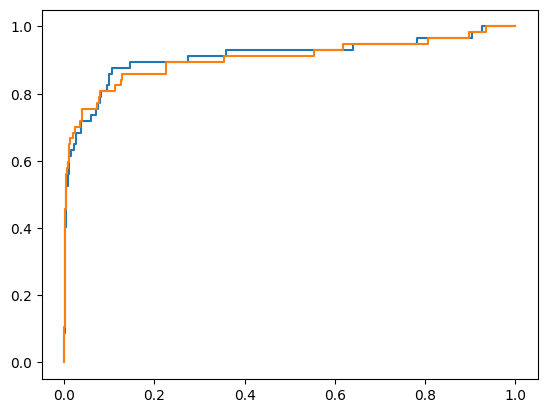

In [225]:
plt.plot(fpr1, tpr1)
plt.plot(fpr2, tpr2)
plt.show()

In [226]:
from sklearn.metrics import auc
auc(fpr1, tpr1), auc(fpr2, tpr2)

(0.9112202563673234, 0.9037227214377407)